# Setup and Imports
This section imports all required libraries for data analysis, loads the dataset into a DataFrame, and defines a utility function that logs completed tasks to a separate .txt file for documentation and reproducibility.

In [1]:
#Import libraries
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Function to record tasks into Travel_Log.txt
from datetime import datetime

def tlog(task_completed, why, tools_used="", notes="", file="travel_log.txt"):
    ts = datetime.now().astimezone().strftime("%Y-%m-%d %H:%M")
    entry = (
        f"[{ts}]\n"
        f"Task completed: {task_completed}\n"
        f"Why I did it: {why}\n"
        f"Tools/commands used (optional): {tools_used}\n"
        f"Notes: {notes}\n\n"
    )
    with open(file, "a", encoding="utf-8") as f:
        f.write(entry)

In [3]:
# Import and read csv file
df = pd.read_csv("customer_service_escalation_risk.csv")

# Data Exploration, Visualisations, and Summary
- Prepare an overview of the dataset, summarising the key features and their characteristics.
- Explore the structure and distribution of variables using appropriate visual and statistical methods.
- Introduce the dataset clearly in report, noting any interesting patterns or potential data quality concerns.

In [4]:
df.sample(10) #Random sample to inspect data

,escalation_level,age,tenure_months,loyalty_status,segment,region,industry,channel,issue_category,issue_subtype,...,behaviour_score_5,ops_telemetry_kpi_1,ops_telemetry_kpi_2,ops_telemetry_kpi_3,ops_telemetry_kpi_4,ops_telemetry_kpi_5,post_interaction_quality_score,risk_indicator,service_pressure_score,customer_engagement_score
12160,Minor escalation,20.0,0,Bronze,Retail,Midlands,Finance,Phone,Billing,Worng item,...,55.6,0.4881,0.8587,-1.1524,-0.9569,0.4965,3.379435,15.834597,14.927663,6.216458
826,Minor escalation,41.0,107,Silver,Retail,Midlands,Retail,Email,Other,Other,...,48.5,-0.3628,-1.3355,-0.0790,1.0373,-0.4507,3.953919,8.784861,13.097969,5.154752
7050,Serious escalation,51.0,18,Silver,Other,Midlands,Finance,Email,Other,Outage,...,42.6,-0.0702,0.1777,-0.4829,0.8954,-0.6618,5.502114,24.758469,13.696838,11.612283
1465,No escalation,54.0,16,Bronze,Retail,Midlands,Tech,Chat,Technical,Password reset,...,65.9,-0.6077,-0.4978,-0.5638,-1.0266,1.5777,-0.180759,0.000000,2.751973,0.000000
364,Legal escalation,36.0,43,Bronze,Retail,Scotland,Finance,Email,Billing,Outage,...,32.8,0.0563,0.7866,0.2068,1.0586,-1.2963,8.406418,48.577318,18.529562,11.087553
6415,No escalation,54.0,42,Bronze,Business,Midlands,Healthcare,Phone,Technical,Locked account,...,66.1,-0.3346,1.8479,1.0165,0.6318,0.1950,0.136336,3.390776,11.346197,NaN
2024,No escalation,50.0,44,Silver,Retail,South East,Tech,Chat,Other,Refund status,...,42.5,0.3409,0.0764,1.3743,-0.6855,-1.7386,0.903508,0.000000,6.206626,3.101293
2960,Serious escalation,30.0,32,Bronze,Retail,Wales,Retail,Chat,Technical,Locked account,...,62.0,0.9695,-1.0353,0.1517,-0.7671,-1.7804,5.509564,34.031859,20.091676,6.411576
5831,No escalation,38.0,87,Gold,Retail,North West,Tech,Email,Billing,Wrong item,...,43.2,-0.2264,0.7135,0.9142,-0.6402,-0.7151,-0.179051,0.000000,10.520081,1.341165
11889,No escalation,38.0,72,Silver,Business,Midlands,Finance,Phone,Technical,Other,...,41.5,0.8054,-0.0074,0.9657,0.3035,1.4236,-0.027264,2.173744,5.923695,0.000000


In [5]:
df.info() #Basic information including data types and NaNs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12362 entries, 0 to 12361
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   escalation_level                12362 non-null  object 
 1   age                             12331 non-null  float64
 2   tenure_months                   12362 non-null  int64  
 3   loyalty_status                  12343 non-null  object 
 4   segment                         12362 non-null  object 
 5   region                          12362 non-null  object 
 6   industry                        12362 non-null  object 
 7   channel                         12362 non-null  object 
 8   issue_category                  12362 non-null  object 
 9   issue_subtype                   12362 non-null  object 
 10  product_line                    12362 non-null  object 
 11  device_type                     12362 non-null  object 
 12  time_of_day_bucket              

In [6]:
df.shape #Check for number of rows/columns

(12362, 41)

In [7]:
df[df.duplicated()] #Check for duplicate rows

,escalation_level,age,tenure_months,loyalty_status,segment,region,industry,channel,issue_category,issue_subtype,...,behaviour_score_5,ops_telemetry_kpi_1,ops_telemetry_kpi_2,ops_telemetry_kpi_3,ops_telemetry_kpi_4,ops_telemetry_kpi_5,post_interaction_quality_score,risk_indicator,service_pressure_score,customer_engagement_score
12240,No escalation,64.0,65,Silver,Retail,Wales,Education,Chat,Billing,Password reset,...,60.1,0.9054,-0.8847,1.2733,0.3218,-0.1293,-0.637369,0.809820,7.821859,NaN
12241,No escalation,25.0,67,Gold,Retail,Midlands,Finance,Phone,Technical,Damaged item,...,51.0,2.4117,-0.6957,0.5792,1.4234,-0.1882,-0.370405,0.000000,4.662303,11.518327
12242,No escalation,23.0,17,Gold,Retail,Midlands,Finance,Chat,Billing,Outage,...,53.8,-0.3823,-0.9180,-0.2530,-1.4352,1.1338,0.505662,0.000000,6.116466,5.774076
12243,Minor escalation,39.0,51,Gold,Student,North West,Finance,Chat,Account,Delayed delivery,...,47.6,0.6831,0.1733,0.4972,-0.1135,0.2610,2.133753,25.553028,10.604763,9.256505
12244,Minor escalation,51.0,0,Bronze,Retail,South East,Retail,Phone,Orders,Outage,...,56.0,-0.0336,0.1786,-1.4131,-0.9482,0.1642,2.228155,12.503427,10.445700,6.063480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12357,Minor escalation,44.0,39,Silver,Retail,Midlands,Education,In-app,Orders,Invoice error,...,33.3,-1.2574,-1.6334,1.2038,0.5498,0.6220,3.517238,19.191677,5.380710,8.260038
12358,Legal escalation,51.0,100,Gold,Retail,London,Finance,Chat,Billing,Payment failed,...,66.7,0.0715,-1.9532,-0.1106,-0.0563,-1.8971,9.412911,47.458833,16.016410,12.109495
12359,No escalation,35.0,59,Bronze,Retail,North West,Tech,Phone,Technical,Other,...,43.2,-1.1632,0.0014,-0.6453,-0.8185,1.4606,0.771939,0.000000,5.974300,2.679134
12360,No escalation,83.0,0,Bronze,Enterprise,London,Hospitality,In-app,Account,Other,...,67.2,0.9176,-1.6990,0.3025,-0.9166,-0.3655,-0.225614,0.000000,7.764019,6.231078


In [8]:
print(df.isnull().sum() * 100 / len(df)) #Check for missing values (Percentage)

escalation_level                  0.000000
age                               0.250768
tenure_months                     0.000000
loyalty_status                    0.153697
segment                           0.000000
region                            0.000000
industry                          0.000000
channel                           0.000000
issue_category                    0.000000
issue_subtype                     0.000000
product_line                      0.000000
device_type                       0.000000
time_of_day_bucket                0.129429
wait_time_seconds                 0.000000
previous_interactions_30d         0.000000
resolution_time_minutes           0.000000
agent_experience_years            1.795826
first_contact_resolution          0.000000
number_of_transfers               0.000000
SLA_breaches_last_6m              0.000000
lifetime_tickets                  0.000000
average_response_delay            0.000000
sentiment_score                   5.096263
monthly_fee

In [9]:
df.nunique() #Check unique values in each column

escalation_level                      4
age                                  74
tenure_months                       126
loyalty_status                        4
segment                               5
region                               47
industry                              6
channel                               4
issue_category                        6
issue_subtype                       106
product_line                          4
device_type                           4
time_of_day_bucket                    4
wait_time_seconds                   511
previous_interactions_30d             8
resolution_time_minutes             146
agent_experience_years              107
first_contact_resolution              2
number_of_transfers                   6
SLA_breaches_last_6m                  6
lifetime_tickets                     82
average_response_delay              588
sentiment_score                   11386
monthly_fee                        5498
subscription_value_str            10535


In [10]:
print (df['escalation_level'].value_counts(normalize=True) * 100) # Escalation level balance percentage

escalation_level
No escalation         48.883676
Minor escalation      30.440058
Serious escalation    16.712506
Legal escalation       3.963760
Name: proportion, dtype: float64


In [11]:
df.describe() #Summary stats

,age,tenure_months,wait_time_seconds,previous_interactions_30d,resolution_time_minutes,agent_experience_years,number_of_transfers,SLA_breaches_last_6m,lifetime_tickets,average_response_delay,...,behaviour_score_5,ops_telemetry_kpi_1,ops_telemetry_kpi_2,ops_telemetry_kpi_3,ops_telemetry_kpi_4,ops_telemetry_kpi_5,post_interaction_quality_score,risk_indicator,service_pressure_score,customer_engagement_score
count,12331.000000,12362.000000,12362.00000,12362.000000,12362.000000,12140.000000,12362.000000,12362.000000,12362.000000,12362.000000,...,12362.000000,12362.000000,12362.000000,12362.000000,12362.000000,12362.000000,12362.000000,12182.000000,12175.000000,11536.000000
mean,39.422269,37.058809,184.20741,1.201424,42.750283,3.564629,0.608801,0.405193,15.903656,2.405965,...,50.028580,-0.008051,-0.002082,0.005103,-0.002912,-0.004452,2.277461,12.574592,10.731713,6.566629
std,14.999103,25.404541,104.74980,1.097189,26.365153,2.093282,0.781747,0.631879,11.336211,1.181518,...,14.872114,1.004418,0.992245,1.005364,1.005497,1.004306,2.676072,13.273211,5.208982,4.290960
min,18.000000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,-3.749600,-3.716000,-3.587800,-3.638200,-3.763400,-2.209529,0.000000,0.000000,0.000000
25%,31.000000,17.000000,112.00000,0.000000,24.000000,2.100000,0.000000,0.000000,8.000000,1.570000,...,39.700000,-0.670900,-0.680925,-0.675300,-0.690525,-0.680900,0.006879,0.089078,7.031102,3.330394
50%,39.000000,36.000000,181.00000,1.000000,42.000000,3.500000,0.000000,0.000000,13.000000,2.390000,...,49.900000,-0.002100,-0.007200,0.003050,-0.006700,-0.001300,1.950978,8.999885,10.367573,6.192230
75%,47.000000,54.000000,249.00000,2.000000,59.000000,5.000000,1.000000,1.000000,21.000000,3.210000,...,60.200000,0.666400,0.672175,0.681275,0.673075,0.675375,3.669566,20.220307,14.076289,9.308995
max,663.000000,141.000000,1520.00000,7.000000,470.000000,12.000000,5.000000,5.000000,93.000000,7.270000,...,100.000000,4.093700,3.385300,3.792500,3.600500,3.725600,10.881570,61.197415,49.248254,29.880499


### Figure 1

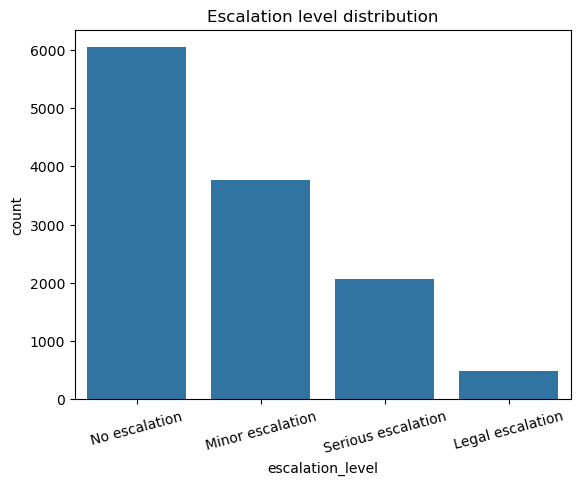

In [12]:
sns.countplot(x='escalation_level', data=df, # Numeric class distribution of escalation level
              order=['No escalation', 'Minor escalation', 'Serious escalation', 'Legal escalation'])
plt.tick_params(axis='x', rotation=15)
plt.title('Escalation level distribution')
plt.show()

### Figure 2

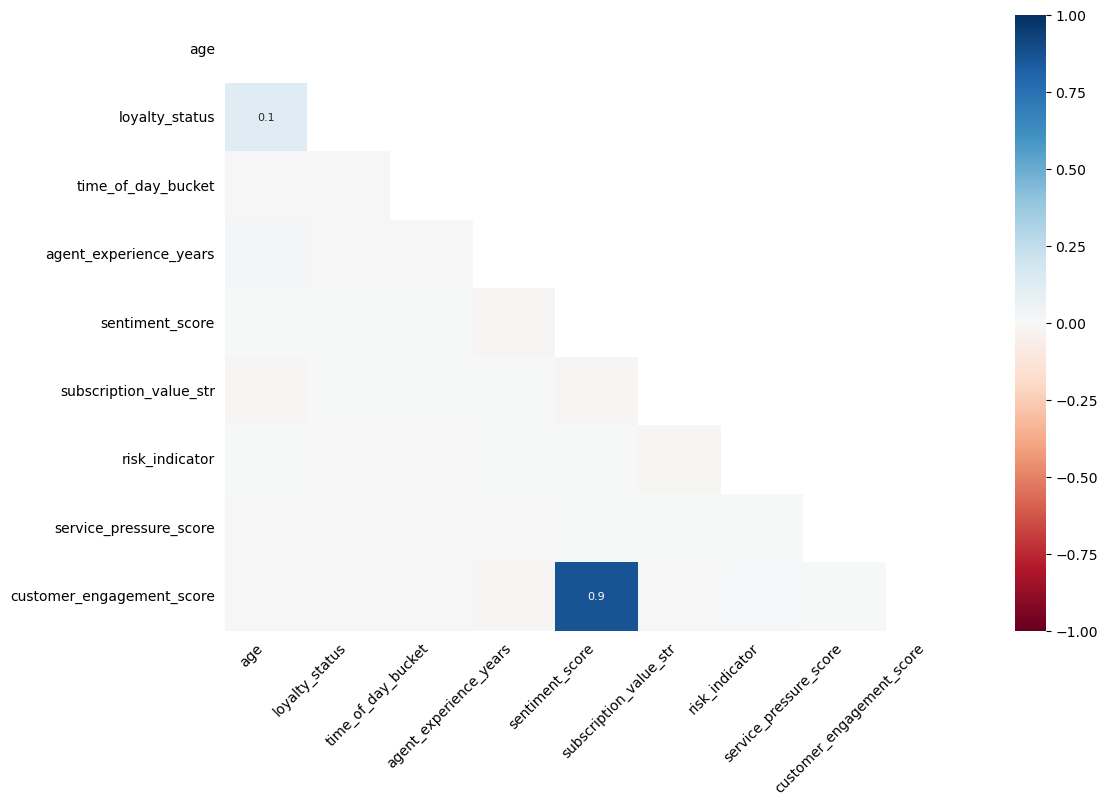

In [13]:
import missingno as msno # AI suggested library
msno.heatmap(df, figsize=(12, 8), fontsize=10) # Show patterns (missingness correlation across columns)
plt.show()

### Figure 3

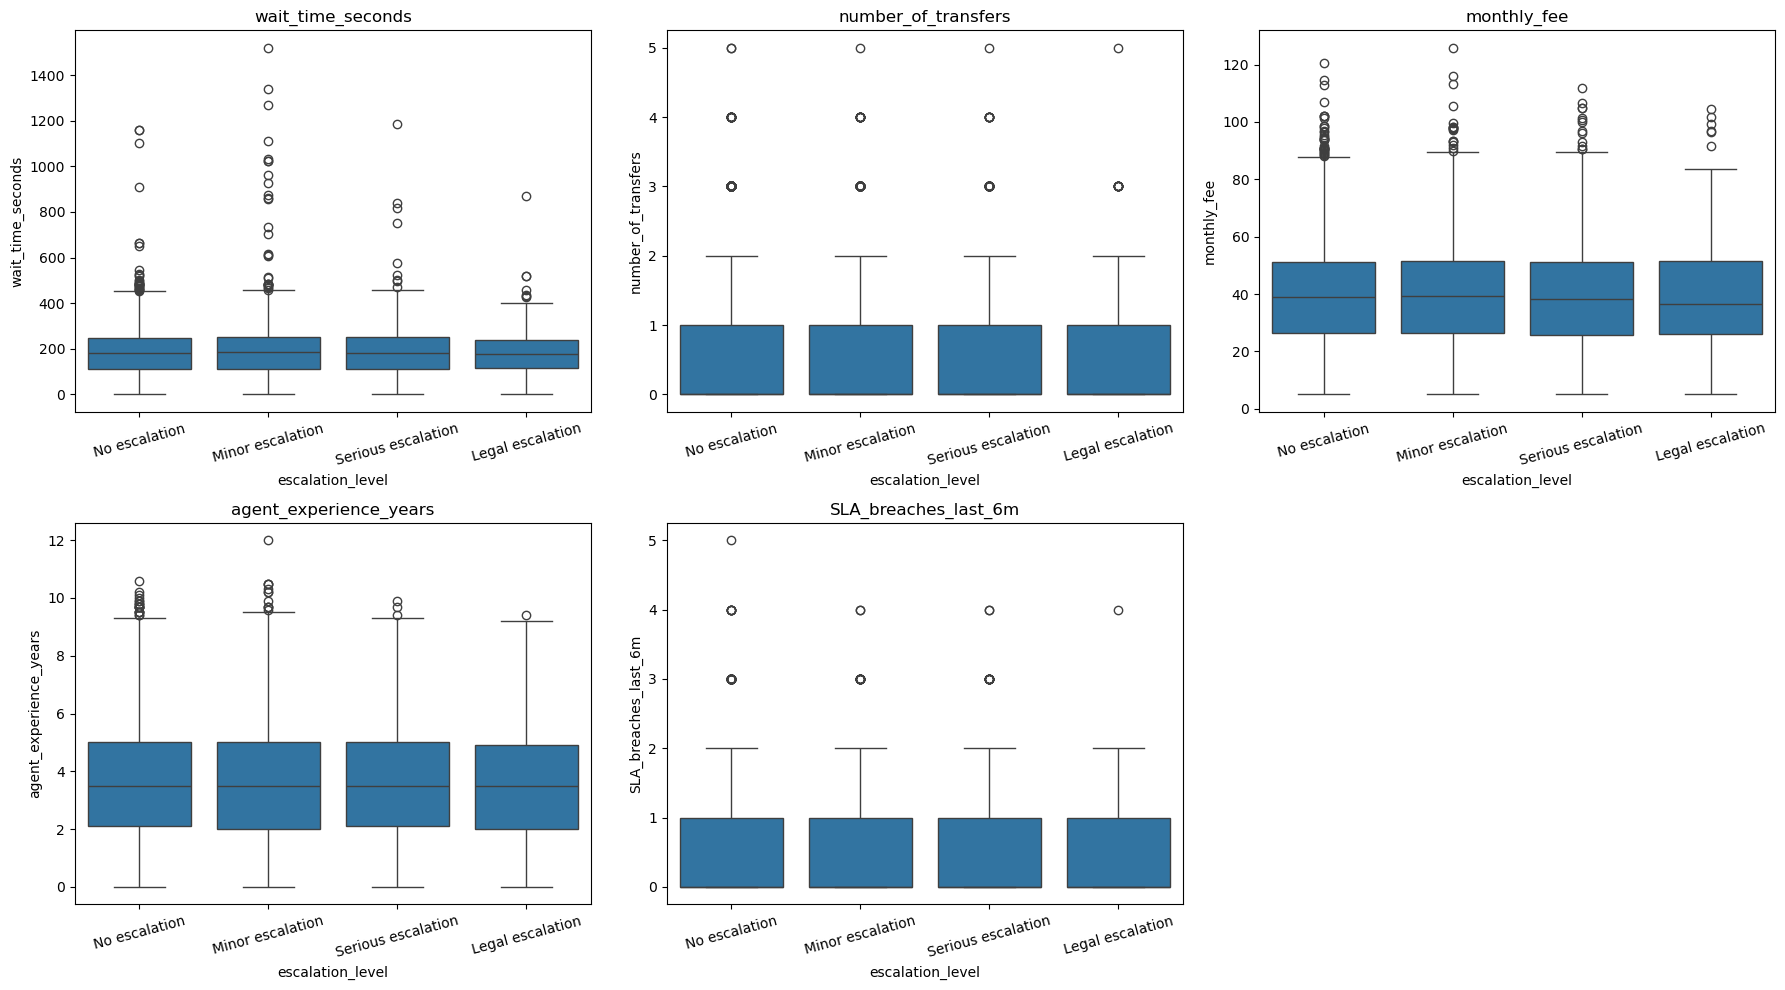

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10)) # Escalation level vs some numeric features (boxplots) AI retrieved

for ax, col in zip(axes.flatten(), ['wait_time_seconds', 'number_of_transfers', 'monthly_fee', 
                                     'agent_experience_years', 'SLA_breaches_last_6m']):
    sns.boxplot(x='escalation_level', y=col, data=df, ax=ax,
                order=['No escalation', 'Minor escalation', 'Serious escalation', 'Legal escalation'])
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=15)

axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

### Figure 4

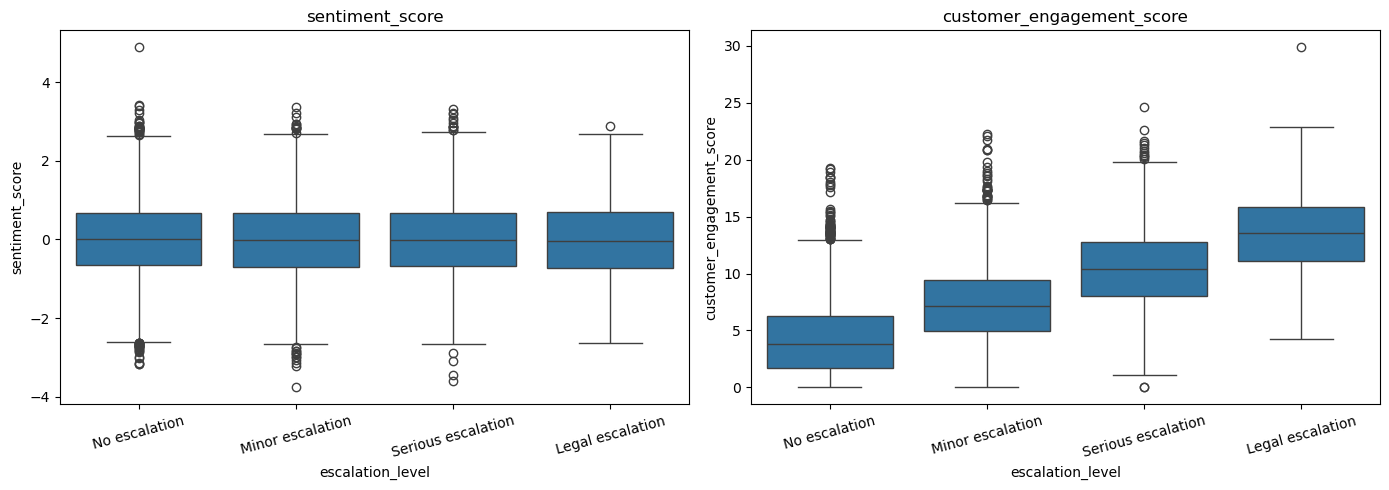

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) #Sentiment and engagement vs escalation level

for ax, col in zip(axes, ['sentiment_score', 'customer_engagement_score']):
    sns.boxplot(x='escalation_level', y=col, data=df, ax=ax, order=['No escalation', 'Minor escalation', 'Serious escalation', 'Legal escalation'])
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Figure 5

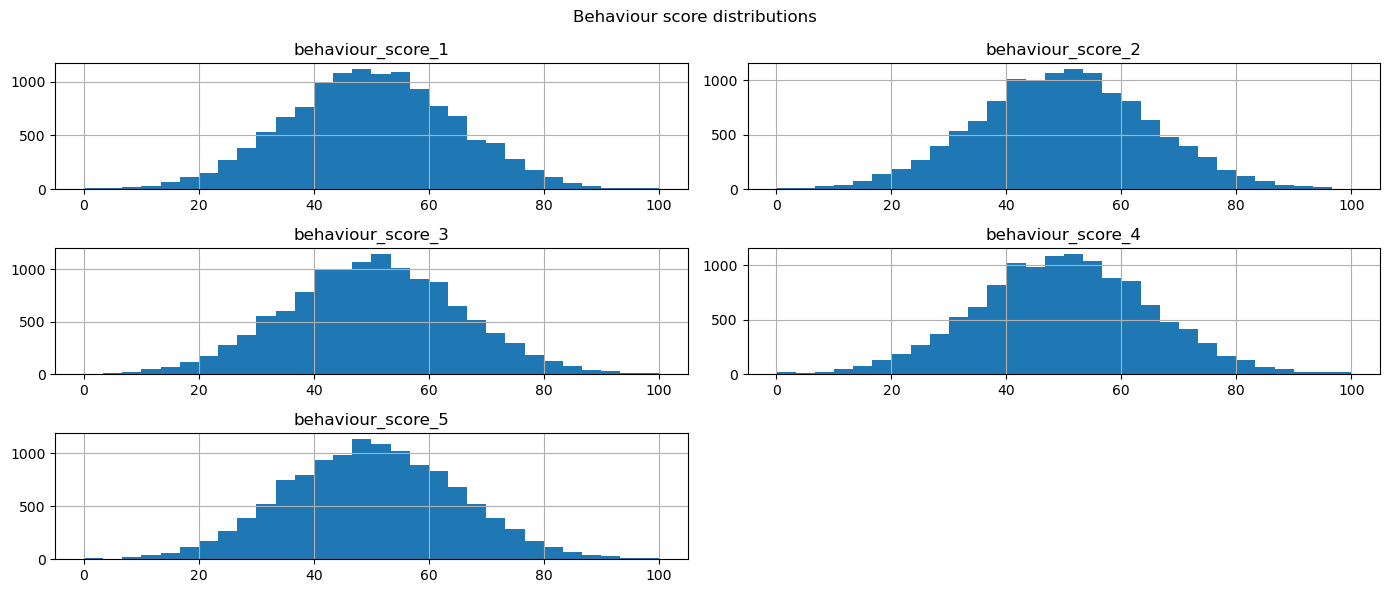

In [16]:
# Behaviour scores distribution (Check if these are all on the same scale)
behaviour_cols = ['behaviour_score_1', 'behaviour_score_2', 'behaviour_score_3',
                  'behaviour_score_4', 'behaviour_score_5']

df[behaviour_cols].hist(figsize=(14, 6), bins=30)
plt.suptitle('Behaviour score distributions')
plt.tight_layout()
plt.show()

## Data Dictionary (Raw)
This section includes initial data dictionary construction. Final data dictionary will be appended.

In [17]:
data_dict = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.values,
    'non_null': df.notnull().sum().values,
    'null_count': df.isnull().sum().values,
    'null_pct': (df.isnull().mean() * 100).round(2).values,
    'unique_values': df.nunique().values
})
data_dict

,column,dtype,non_null,null_count,null_pct,unique_values
0,escalation_level,object,12362,0,0.00,4
1,age,float64,12331,31,0.25,74
2,tenure_months,int64,12362,0,0.00,126
3,loyalty_status,object,12343,19,0.15,4
4,segment,object,12362,0,0.00,5
5,region,object,12362,0,0.00,47
6,industry,object,12362,0,0.00,6
7,channel,object,12362,0,0.00,4
8,issue_category,object,12362,0,0.00,6
9,issue_subtype,object,12362,0,0.00,106


# Data Cleansing, Feature Engineering, and Pre-processing
- Apply any cleansing, transformation, or pre-processing operations.
- Identify variables that may be unsuitable for prediction due to meaning, timing,
leakage risk, or reliability, and justify whether they should be retained.

## Data Types

In [18]:
# Converting all values to float
df['subscription_value_str'] = df['subscription_value_str'].astype(str).str.replace('[£,]', '', regex=True).astype(float)

df.rename(columns={'subscription_value_str': 'subscription_value'}, inplace=True) #Renamed

In [19]:
df.dtypes['subscription_value'] # Check

dtype('float64')

In [20]:
if df['first_contact_resolution'].dtype == 'object': # Convert to binary integer
    df['first_contact_resolution'] = df['first_contact_resolution'].map({'Yes': 1, 'No': 0})
print(df['first_contact_resolution'].value_counts())

first_contact_resolution
1    8922
0    3440
Name: count, dtype: int64


In [21]:
df['priority_flag'].value_counts() #Check if binary

priority_flag
No     10067
Yes     2295
Name: count, dtype: int64

## String Cleaning

In [22]:
for col in df.select_dtypes(include='object').columns: #Check for inconsistent spelling
    df[col] = df[col].str.strip().str.lower()

In [23]:
for col in df.select_dtypes(include='object').columns: # Check spelling or near duplicates
    print(col, df[col].unique())

escalation_level ['minor escalation' 'no escalation' 'serious escalation'
 'legal escalation']
loyalty_status ['bronze' 'silver' 'gold' nan 'platinum']
segment ['retail' 'business' 'enterprise' 'student' 'other']
region ['london' 'south east' 'wales' 'scotland' 'north west' 'midlands' 'lodnon'
 'sotuh east' 'olndon' 'midlnads' 'londno' 'imdlands' 'midladns'
 'souht east' 'awles' 'midlansd' 'north wets' 'north ewst' 'suoth east'
 'waels' 'norht west' 'southe ast' 'northw est' 'osuth east' 'mid-lands'
 'sout heast' 'mdilands' 'lonodn' 'soctland' 'notrh west' 'nroth west'
 'south esat' 'south aest' 'lnodon' 'scotladn' 'midalnds' 'north wset'
 'wlaes' 'south eats' 'onrth west' 'mildands' 'csotland' 'scotlnad'
 'scoltand' 'walse' 'nort hwest' 'scotalnd']
industry ['retail' 'finance' 'hospitality' 'tech' 'education' 'healthcare']
channel ['chat' 'phone' 'email' 'in-app']
issue_category ['technical' 'billing' 'returns' 'orders' 'other' 'account']
issue_subtype ['wrong item' 'locked account' '

In [24]:
from thefuzz import process # AI retrieved (installed pip install thefuzz)
# Correct region/issue spelling into variable
valid_regions = ['south east', 'midlands', 'london', 'north west', 'scotland', 'wales']
valid_issue_subtype = ['other', 'slow internet', 'delayed delivery', 'damaged item', 'wrong item',
                 'password reset', 'invoice error', 'outage', 'refund status', 
                 'locked account', 'payment failed']
#Function that fixes typos in a column by finding the closest correct spelling
def standardise_column(df, col, valid_categories):
    def fix(val):
        if pd.isnull(val):
            return val
        match, score = process.extractOne(val, valid_categories)
        return match if score >= 80 else val
    df[col] = df[col].apply(fix)
    return df

df = standardise_column(df, 'region', valid_regions)
df = standardise_column(df, 'issue_subtype', valid_issue_subtype)

# Verify
print(df['region'].value_counts())
print(df['issue_subtype'].value_counts())

region
south east    2919
midlands      2586
london        2556
north west    1845
scotland      1455
wales         1001
Name: count, dtype: int64
issue_subtype
other               1174
slow internet       1143
damaged item        1139
delayed delivery    1136
wrong item          1131
outage              1124
password reset      1119
invoice error       1111
refund status       1102
locked account      1098
payment failed      1085
Name: count, dtype: int64


In [25]:
# Check for duplicates after string cleaning
print(f'Duplicates before: {df.duplicated().sum()}')

Duplicates before: 122


In [26]:
df.drop_duplicates(inplace=True) #Drop duplicates
print(f'Duplicates after: {df.duplicated().sum()}')

Duplicates after: 0


## Outliers

In [27]:
print(df[df['age'] > 120]['age'].value_counts()) #Check age column outliers

age
245.0    1
630.0    1
155.0    1
663.0    1
399.0    1
440.0    1
228.0    1
Name: count, dtype: int64


In [28]:
df.loc[df['age'] > 120, 'age'] = np.nan #Replace unreasonable values with NaNs and impute w/ median
df['age'] = df['age'].fillna(df['age'].median())

In [29]:
def flag_outliers(df, col): #Check numeric columns outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)].shape[0]

numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    n = flag_outliers(df, col)
    if n > 0:
        print(f'{col}: {n} outliers')

age: 43 outliers
tenure_months: 40 outliers
wait_time_seconds: 71 outliers
previous_interactions_30d: 21 outliers
resolution_time_minutes: 65 outliers
agent_experience_years: 41 outliers
number_of_transfers: 303 outliers
SLA_breaches_last_6m: 91 outliers
lifetime_tickets: 311 outliers
average_response_delay: 45 outliers
sentiment_score: 90 outliers
monthly_fee: 70 outliers
subscription_value: 41 outliers
behaviour_score_1: 95 outliers
behaviour_score_2: 94 outliers
behaviour_score_3: 78 outliers
behaviour_score_4: 104 outliers
behaviour_score_5: 70 outliers
ops_telemetry_kpi_1: 97 outliers
ops_telemetry_kpi_2: 68 outliers
ops_telemetry_kpi_3: 78 outliers
ops_telemetry_kpi_4: 85 outliers
ops_telemetry_kpi_5: 84 outliers
post_interaction_quality_score: 184 outliers
risk_indicator: 107 outliers
service_pressure_score: 83 outliers
customer_engagement_score: 99 outliers


In [30]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

In [31]:
cols_to_cap = [ #Cap extreme values
    'wait_time_seconds', 'resolution_time_minutes', 'average_response_delay',
    'number_of_transfers', 'SLA_breaches_last_6m', 'lifetime_tickets',
    'previous_interactions_30d', 'monthly_fee', 'subscription_value',
    'sentiment_score', 'customer_engagement_score', 'risk_indicator',
    'service_pressure_score', 'behaviour_score_1', 'behaviour_score_2',
    'behaviour_score_3', 'behaviour_score_4', 'behaviour_score_5',
    'ops_telemetry_kpi_1', 'ops_telemetry_kpi_2', 'ops_telemetry_kpi_3',
    'ops_telemetry_kpi_4', 'ops_telemetry_kpi_5']

for col in cols_to_cap:
    df = cap_outliers(df, col)

In [32]:
print(df[cols_to_cap].describe().loc[['min', 'max']]) #Check

     wait_time_seconds  resolution_time_minutes  average_response_delay  \
min                0.0                      1.0                    0.00   
max              454.5                    111.5                    5.67   

     number_of_transfers  SLA_breaches_last_6m  lifetime_tickets  \
min                  0.0                   0.0               1.0   
max                  2.5                   2.5              43.0   

     previous_interactions_30d  monthly_fee  subscription_value  \
min                        0.0        5.000              50.000   
max                        5.0       88.775            1080.625   

     sentiment_score  ...  behaviour_score_1  behaviour_score_2  \
min        -2.682905  ...               10.7                9.5   
max         2.674903  ...               89.1               90.3   

     behaviour_score_3  behaviour_score_4  behaviour_score_5  \
min                9.9                9.6               8.95   
max               90.7               

In [33]:
print(df['age'].isna().sum()) # Check for NaNs
print(df['age'].describe()) # Confirm max

0
count    12240.000000
mean        39.216422
std         11.566162
min         18.000000
25%         31.000000
50%         39.000000
75%         47.000000
max         90.000000
Name: age, dtype: float64


## Missing Values

In [34]:
#Created flag before imputing
df['sentiment_engagement_missing'] = (
    df['sentiment_score'].isnull() | df['customer_engagement_score'].isnull()
).astype(int)

In [35]:
numeric_to_impute = ['age', 'agent_experience_years', 'risk_indicator',
                     'service_pressure_score', 'subscription_value']

for col in numeric_to_impute: # Numeric imputation
    df[col] = df[col].fillna(df[col].median())

categorical_to_impute = ['loyalty_status', 'time_of_day_bucket'] 

for col in categorical_to_impute: # Categorical imputation
    df[col] = df[col].fillna(df[col].mode()[0])

# Impute sentiment and engagement with median
df['sentiment_score'] = df['sentiment_score'].fillna(df['sentiment_score'].median())
df['customer_engagement_score'] = df['customer_engagement_score'].fillna(df['customer_engagement_score'].median())

In [36]:
# Verify no nulls remain
print(df.isnull().sum()[df.isnull().sum() > 0])
print(df['sentiment_engagement_missing'].value_counts())

Series([], dtype: int64)
sentiment_engagement_missing
0    11422
1      818
Name: count, dtype: int64


## Leakage Risks

In [37]:
#Dropping columns
df.drop(columns=['post_interaction_quality_score', 'resolution_time_minutes', 'first_contact_resolution'], inplace=True)

In [38]:
print(df.shape) #Check if columns dropped
print(df.columns.tolist())

(12240, 39)
['escalation_level', 'age', 'tenure_months', 'loyalty_status', 'segment', 'region', 'industry', 'channel', 'issue_category', 'issue_subtype', 'product_line', 'device_type', 'time_of_day_bucket', 'wait_time_seconds', 'previous_interactions_30d', 'agent_experience_years', 'number_of_transfers', 'SLA_breaches_last_6m', 'lifetime_tickets', 'average_response_delay', 'sentiment_score', 'monthly_fee', 'subscription_value', 'churn_risk_band', 'priority_flag', 'behaviour_score_1', 'behaviour_score_2', 'behaviour_score_3', 'behaviour_score_4', 'behaviour_score_5', 'ops_telemetry_kpi_1', 'ops_telemetry_kpi_2', 'ops_telemetry_kpi_3', 'ops_telemetry_kpi_4', 'ops_telemetry_kpi_5', 'risk_indicator', 'service_pressure_score', 'customer_engagement_score', 'sentiment_engagement_missing']


## Class Balance

In [39]:
df['escalation_level'].value_counts(normalize=True) * 100 #Check target variable

escalation_level
no escalation         48.937908
minor escalation      30.416667
serious escalation    16.699346
legal escalation       3.946078
Name: proportion, dtype: float64

##  Feature Engineering

In [40]:
# Total operational burden
df['total_burden'] = df['number_of_transfers'] + df['SLA_breaches_last_6m']

# High risk flag
df['high_risk'] = ((df['churn_risk_band'] == 'high') & (df['priority_flag'] == 1)).astype(int)

# Interaction history ratio
df['recent_interaction_ratio'] = df['previous_interactions_30d'] / (df['lifetime_tickets'] + 1)

## Encode Categorials

In [41]:
# Convert priority flag to binary
df['priority_flag'] = df['priority_flag'].map({'yes': 1, 'no': 0})
# Encode nominal categoricals
nominal_cols = ['channel', 'issue_category', 'issue_subtype', 'product_line',
                'device_type', 'region', 'industry', 'segment',
                'time_of_day_bucket', 'churn_risk_band', 'loyalty_status']
#AI and additional learning materials retrieved
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True) #Missing column for features w/ many categories

# Label encode the target
from sklearn.preprocessing import LabelEncoder #Help from video https://youtu.be/YvEx0IGKTko?si=CIgoZRYHGpY8xXhv
le = LabelEncoder()
df['escalation_level_enc'] = le.fit_transform(df['escalation_level'])

# Verify
print(df.shape)
print(df.columns.tolist())
print(df['escalation_level_enc'].value_counts())

(12240, 78)
['escalation_level', 'age', 'tenure_months', 'wait_time_seconds', 'previous_interactions_30d', 'agent_experience_years', 'number_of_transfers', 'SLA_breaches_last_6m', 'lifetime_tickets', 'average_response_delay', 'sentiment_score', 'monthly_fee', 'subscription_value', 'priority_flag', 'behaviour_score_1', 'behaviour_score_2', 'behaviour_score_3', 'behaviour_score_4', 'behaviour_score_5', 'ops_telemetry_kpi_1', 'ops_telemetry_kpi_2', 'ops_telemetry_kpi_3', 'ops_telemetry_kpi_4', 'ops_telemetry_kpi_5', 'risk_indicator', 'service_pressure_score', 'customer_engagement_score', 'sentiment_engagement_missing', 'total_burden', 'high_risk', 'recent_interaction_ratio', 'channel_email', 'channel_in-app', 'channel_phone', 'issue_category_billing', 'issue_category_orders', 'issue_category_other', 'issue_category_returns', 'issue_category_technical', 'issue_subtype_delayed delivery', 'issue_subtype_invoice error', 'issue_subtype_locked account', 'issue_subtype_other', 'issue_subtype_out

In [42]:
print(dict(zip(le.classes_, le.transform(le.classes_)))) #Verify the label encoding matches correctly

{'legal escalation': np.int64(0), 'minor escalation': np.int64(1), 'no escalation': np.int64(2), 'serious escalation': np.int64(3)}


In [43]:
issue_subtype_cols = [col for col in df.columns if col.startswith('issue_subtype_')]
damaged_item_rows = df[(df[issue_subtype_cols] == 0).all(axis=1)]
print(len(damaged_item_rows)) #Check columns set to 0/rows where the issue subtype encoding is blank

1133


## Train/Test Split and Scale

In [44]:
#Help from video https://youtu.be/SjOfbbfI2qY?si=WBBwbe8XzLNu-TgY
from sklearn.model_selection import train_test_split #Imports library
from sklearn.preprocessing import StandardScaler # Import the tool that scales

X = df.drop(columns=['escalation_level', 'escalation_level_enc']) # Every column except the target
y = df['escalation_level_enc'] #Just the target column

X_train, X_test, y_train, y_test = train_test_split( #Split both X and y into two groups
    X, y, test_size=0.2, stratify=y, random_state=42) # Keep 20% for testing, 80% goes to training

In [45]:
scaler = StandardScaler() #Everything on the same scale
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))

(9792, 76) (2448, 76)
escalation_level_enc
2    0.489
1    0.304
3    0.167
0    0.040
Name: proportion, dtype: float64


In [46]:
# Check sizes
print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")
print(f"Total: {X_train.shape[0] + X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

# Check stratification
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3))

Training rows: 9792
Testing rows: 2448
Total: 12240
Features: 76

Train class distribution:
escalation_level_enc
2    0.489
1    0.304
3    0.167
0    0.040
Name: proportion, dtype: float64


# Supervised Model Training, and Tuning
- Develop predictive models using tools and libraries (e.g. k-NN, Decision Trees, SVMs, ensembles, neural networks, etc.).
- Perform reasonable hyperparameter tuning to improve model performances.
- Evaluate models using suitable metrics for a multiclass problem, including comparative analysis.
- Provide interpretation of model behaviour, including identification of influential factors or variables.

## Logistic Regression (Baseline model, no tuning)

### Figure 6

=== Logistic Regression (Baseline) ===
                    precision    recall  f1-score   support

  legal escalation       0.83      0.95      0.88        96
  minor escalation       0.94      0.95      0.94       745
     no escalation       0.99      0.97      0.98      1198
serious escalation       0.93      0.92      0.92       409

          accuracy                           0.96      2448
         macro avg       0.92      0.95      0.93      2448
      weighted avg       0.96      0.96      0.96      2448



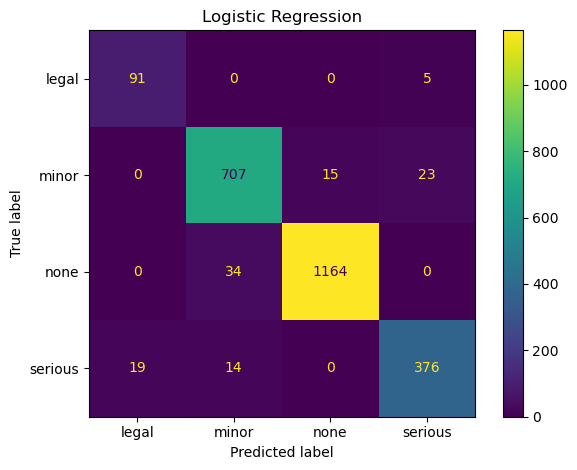

In [47]:
from sklearn.linear_model import LogisticRegression #Help from video https://youtu.be/aL21Y-u0SRs?si=9mb3Vnijy1CUExjO
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Baseline Logistic Regression (no tuning, class weight to handle imbalance)
lr_baseline = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

y_pred_lr = lr_baseline.predict(X_test_scaled)

print("=== Logistic Regression (Baseline) ===")
print(classification_report(y_test, y_pred_lr,
      target_names=['legal escalation', 'minor escalation', 'no escalation', 'serious escalation']))

ConfusionMatrixDisplay.from_estimator(lr_baseline, X_test_scaled, y_test,
    display_labels=['legal', 'minor', 'none', 'serious'])
plt.title("Logistic Regression")
plt.tight_layout()
plt.show()

## Decision Tree (Tuned)

### Figures 7 and 8

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 7, 'criterion': 'entropy'}
Best CV macro F1: 0.8969

=== Decision Tree (Tuned) ===
                    precision    recall  f1-score   support

  legal escalation       0.91      0.96      0.93        96
  minor escalation       0.88      0.90      0.89       745
     no escalation       0.96      0.94      0.95      1198
serious escalation       0.91      0.92      0.91       409

          accuracy                           0.93      2448
         macro avg       0.91      0.93      0.92      2448
      weighted avg       0.93      0.93      0.93      2448



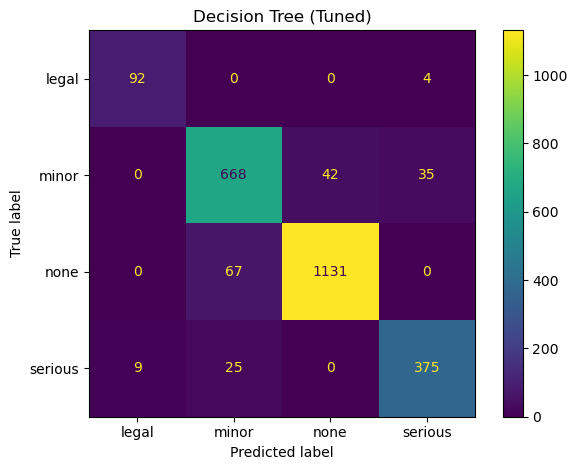

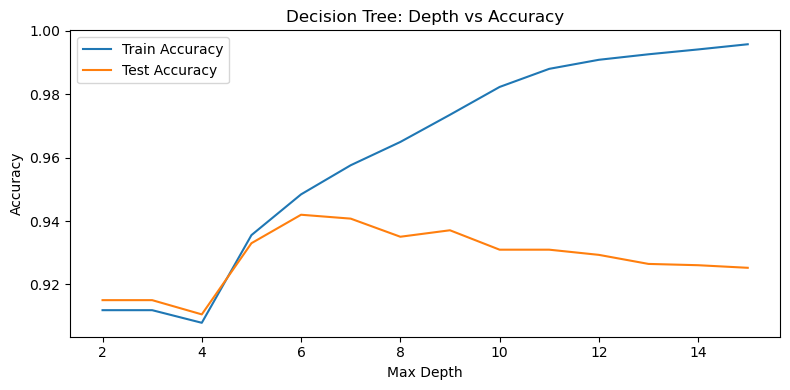

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
# Help from video https://youtu.be/wxS5P7yDHRA?si=-9_mwZymOPfCdE6P
# Find best depth first
param_dist = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']}

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dt_search = RandomizedSearchCV( #Help from video https://youtu.be/PPohAc07TSo?si=j58bpneeGyvFifaI
    dt, param_dist,
    n_iter=30,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1)

dt_search.fit(X_train_scaled, y_train)

print(f"Best params: {dt_search.best_params_}")
print(f"Best CV macro F1: {dt_search.best_score_:.4f}")

# Evaluate best model
best_dt = dt_search.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)

print("\n=== Decision Tree (Tuned) ===")
print(classification_report(y_test, y_pred_dt,
      target_names=['legal escalation', 'minor escalation', 'no escalation', 'serious escalation']))

ConfusionMatrixDisplay.from_estimator(best_dt, X_test_scaled, y_test,
    display_labels=['legal', 'minor', 'none', 'serious'])
plt.title("Decision Tree (Tuned)")
plt.tight_layout()
plt.show()

# Visualise tree
depths = range(2, 16)
train_scores, test_scores = [], []
for d in depths:
    dt_d = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    dt_d.fit(X_train_scaled, y_train)
    train_scores.append(dt_d.score(X_train_scaled, y_train))
    test_scores.append(dt_d.score(X_test_scaled, y_test))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_scores, label='Train Accuracy')
plt.plot(depths, test_scores, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Depth vs Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Random Forest

### Figures 9 and 10

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}
Best CV macro F1: 0.9168

=== Random Forest (Tuned) ===
                    precision    recall  f1-score   support

  legal escalation       0.97      0.88      0.92        96
  minor escalation       0.91      0.94      0.92       745
     no escalation       0.98      0.96      0.97      1198
serious escalation       0.92      0.93      0.92       409

          accuracy                           0.95      2448
         macro avg       0.94      0.93      0.93      2448
      weighted avg       0.95      0.95      0.95      2448



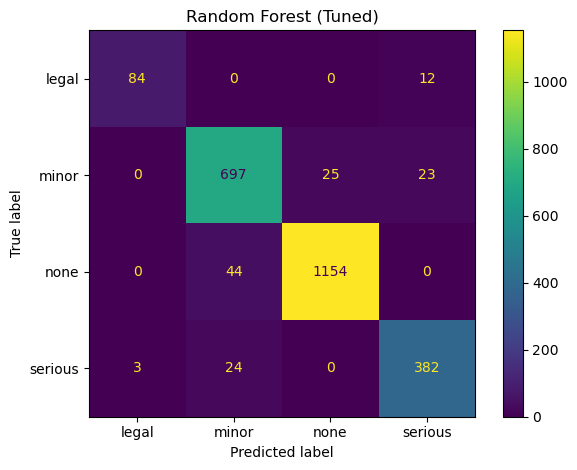

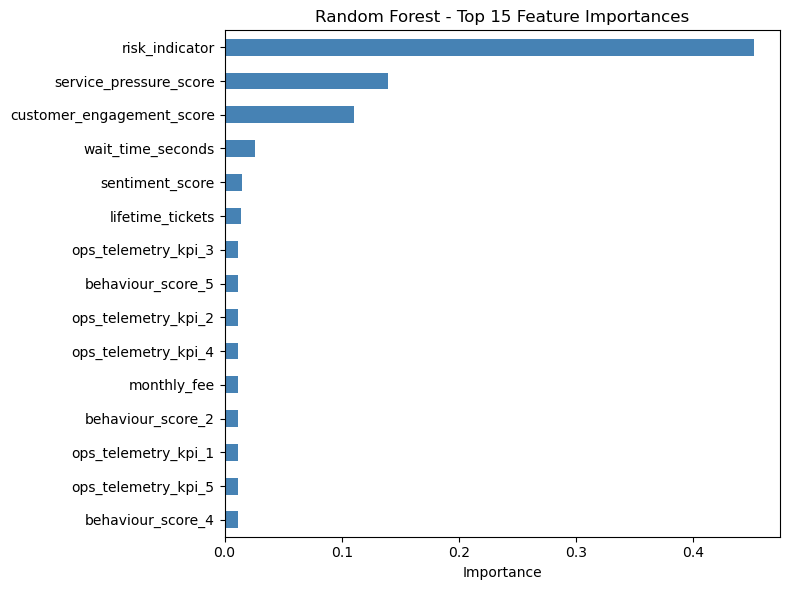

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV( #Help from video https://youtu.be/_QuGM_FW9eo?si=CEfpJch2fvlR9HhP
    rf, param_dist_rf,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1)

rf_search.fit(X_train_scaled, y_train)

print(f"Best params: {rf_search.best_params_}")
print(f"Best CV macro F1: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

print("\n=== Random Forest (Tuned) ===")
print(classification_report(y_test, y_pred_rf,
      target_names=['legal escalation', 'minor escalation', 'no escalation', 'serious escalation']))

ConfusionMatrixDisplay.from_estimator(best_rf, X_test_scaled, y_test,
    display_labels=['legal', 'minor', 'none', 'serious'])
plt.title("Random Forest (Tuned)")
plt.tight_layout()
plt.show()

# Feature importance
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top15 = importances.nlargest(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title('Random Forest - Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Gradient Boosting

### Figure 11

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'min_samples_leaf': 30, 'max_iter': 200, 'max_depth': 3, 'learning_rate': 0.1, 'l2_regularization': 1}
Best CV macro F1: 0.9405

=== Gradient Boosting (Tuned) ===
                    precision    recall  f1-score   support

  legal escalation       0.96      0.95      0.95        96
  minor escalation       0.94      0.95      0.95       745
     no escalation       0.98      0.98      0.98      1198
serious escalation       0.95      0.94      0.94       409

          accuracy                           0.96      2448
         macro avg       0.96      0.96      0.96      2448
      weighted avg       0.96      0.96      0.96      2448



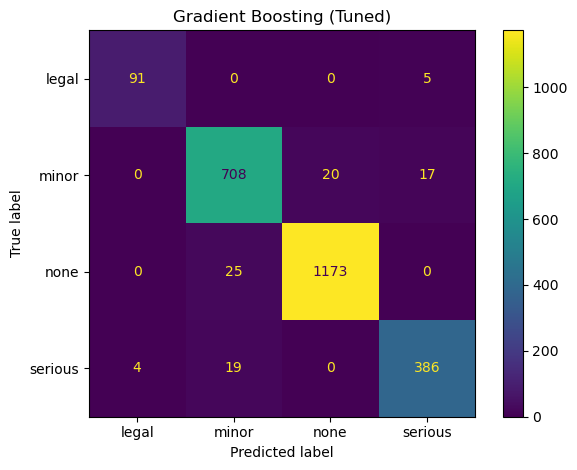

In [50]:
#Help from video https://www.youtube.com/watch?v=aLOQD66Sj0g
# https://youtu.be/E2mCaIZNE2g?si=2v5NA876VXpcY6om
from sklearn.ensemble import HistGradientBoostingClassifier

param_dist_xgb = {
    'max_iter': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [10, 20, 30],
    'l2_regularization': [0, 1, 10]}

hgb = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)

hgb_search = RandomizedSearchCV(
    hgb, param_dist_xgb,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1)

hgb_search.fit(X_train_scaled, y_train)

print(f"Best params: {hgb_search.best_params_}")
print(f"Best CV macro F1: {hgb_search.best_score_:.4f}")

best_hgb = hgb_search.best_estimator_
y_pred_hgb = best_hgb.predict(X_test_scaled)

print("\n=== Gradient Boosting (Tuned) ===")
print(classification_report(y_test, y_pred_hgb,
      target_names=['legal escalation', 'minor escalation', 'no escalation', 'serious escalation']))

ConfusionMatrixDisplay.from_estimator(best_hgb, X_test_scaled, y_test,
    display_labels=['legal', 'minor', 'none', 'serious'])
plt.title("Gradient Boosting (Tuned)")
plt.tight_layout()
plt.show()

## Comparison Visuals

### Figures 12 and 13

                     Accuracy  Macro F1  Weighted F1  ROC-AUC (macro OvR)
Model                                                                    
Logistic Regression    0.9551    0.9326       0.9554               0.9956
Decision Tree          0.9257    0.9218       0.9259               0.9833
Random Forest          0.9465    0.9343       0.9467               0.9925
Gradient Boosting      0.9632    0.9562       0.9633               0.9970


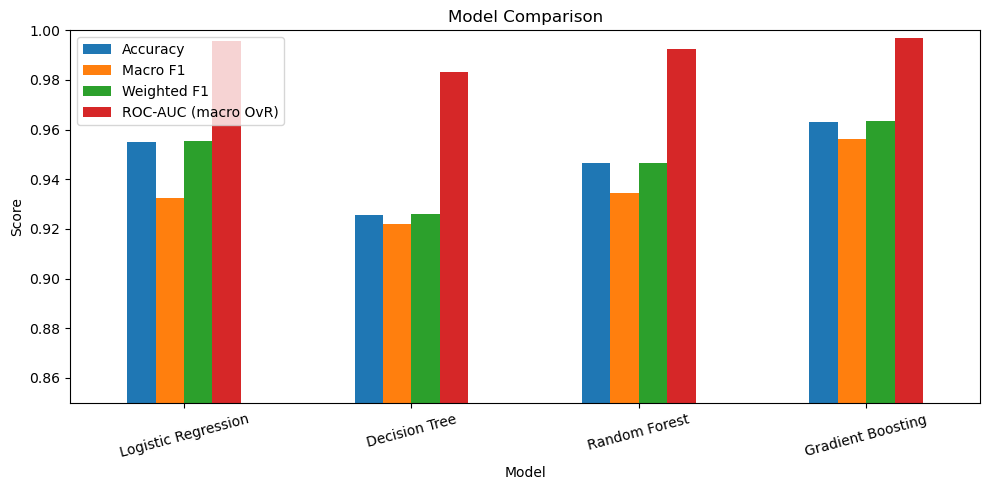

In [51]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
# Help from video https://youtu.be/4jRBRDbJemM?si=SolfTiefbj6wPUVJ
models = {
    'Logistic Regression': (lr_baseline, y_pred_lr),
    'Decision Tree':       (best_dt,     y_pred_dt),
    'Random Forest':       (best_rf,     y_pred_rf),
    'Gradient Boosting':   (best_hgb,    y_pred_hgb)}

results = []
for name, (model, y_pred) in models.items():
    acc     = accuracy_score(y_test, y_pred)
    mac_f1  = f1_score(y_test, y_pred, average='macro')
    wgt_f1  = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test,
                  model.predict_proba(X_test_scaled),
                  multi_class='ovr', average='macro')
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Macro F1': round(mac_f1, 4),
        'Weighted F1': round(wgt_f1, 4),
        'ROC-AUC (macro OvR)': round(roc_auc, 4)})

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

# Visual bar chart comparison
results_df[['Accuracy', 'Macro F1', 'Weighted F1', 'ROC-AUC (macro OvR)']].plot(
    kind='bar', figsize=(10, 5), ylim=(0.85, 1.0), rot=15)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

SHAP values type: <class 'numpy.ndarray'>
3D array shape: (500, 76, 4)


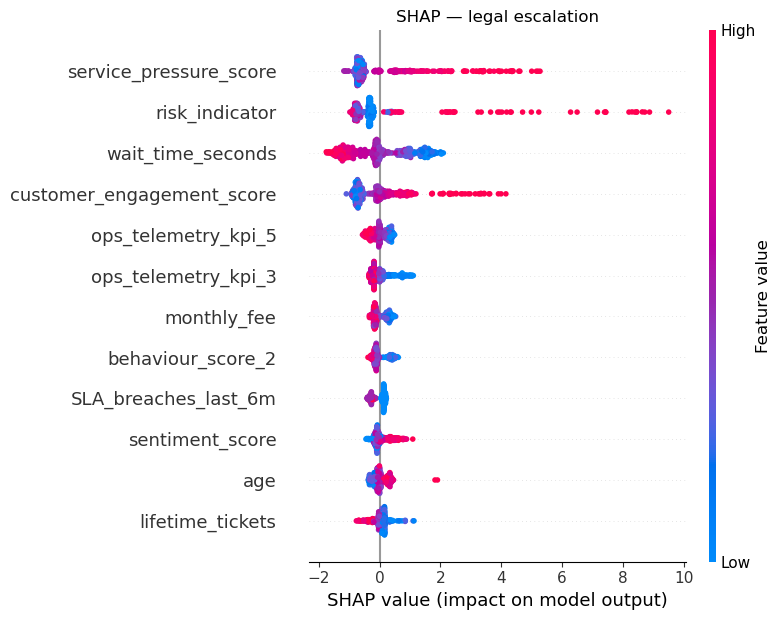

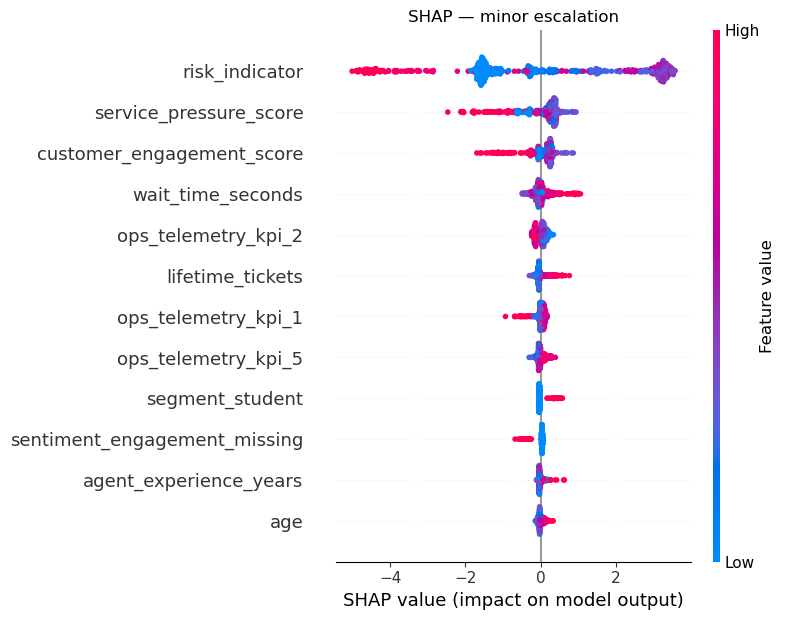

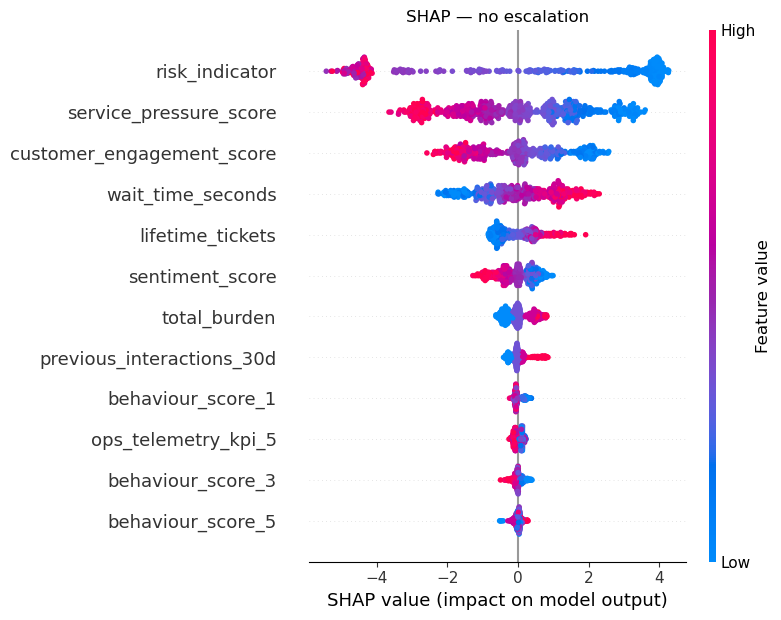

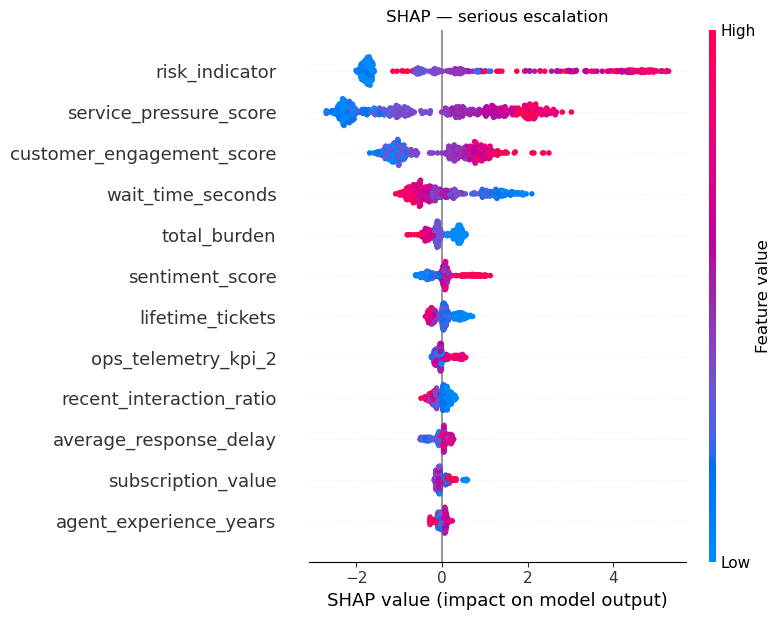

In [52]:
import shap

explainer = shap.TreeExplainer(best_hgb)

X_test_df = pd.DataFrame(X_test_scaled[:500], columns=X_train.columns)
shap_values = explainer.shap_values(X_test_df)

class_names = ['legal escalation', 'minor escalation', 'no escalation', 'serious escalation']

# Check shape to handle both list and array outputs. Help from video https://www.youtube.com/watch?v=L8_sVRhBDLU
print(f"SHAP values type: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Number of classes: {len(shap_values)}, shape per class: {shap_values[0].shape}")
    for i, cls in enumerate(class_names):
        shap.summary_plot(shap_values[i], X_test_df, max_display=12, show=False)
        plt.title(f'SHAP — {cls}')
        plt.tight_layout()
        plt.show()
else:
    print(f"3D array shape: {shap_values.shape}")
    for i, cls in enumerate(class_names):
        shap.summary_plot(shap_values[:, :, i], X_test_df, max_display=12, show=False)
        plt.title(f'SHAP — {cls}')
        plt.tight_layout()
        plt.show()

# Unsupervised Learning Using Clustering Algorithms
- Perform clustering after removing the target variable ‘escalation_level’.
- Choose any data representation appropriate (e.g. encoding, normalisation, dimensionality reduction as needed).
- Apply different clustering methods (e.g. k-Means, hierarchical clustering, etc.) and compare them.
- Use suitable visualisation techniques (e.g. scatterplots, PCA, t-SNE) to illustrate cluster structure.
- Analyse how clusters relate to escalation levels.

## Data Preparation for Clustering

In [53]:
from sklearn.decomposition import PCA #Help from video https://youtu.be/QdBy02ExhGI?si=c12rQDKvBOb_36cr
#Removes the target, scales features, uses PCA to reduce to two dimensions
X_clust = df.drop(columns=['escalation_level_enc', 'escalation_level']) # Drop target

# Scale
X_scaled = StandardScaler().fit_transform(X_clust)

# PCA for all plots
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print(f"Shape ready for clustering: {X_scaled.shape}")

Shape ready for clustering: (12240, 76)


## Comparing Clustering Models

In [54]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN #Help from video https://youtu.be/EZ-M2Imi38A?si=JgLs-a0b-XcyDpAg
from sklearn.metrics import silhouette_score, adjusted_rand_score

km    = KMeans(n_clusters=4, n_init=10, random_state=42) #Groups customers into four clusters 
agg   = AgglomerativeClustering(n_clusters=4, linkage='ward') #Merges the most similar customers into clusters
db    = DBSCAN(eps=3, min_samples=10) #Looks for dense crowds of points

km_labels  = km.fit_predict(X_2d)
agg_labels = agg.fit_predict(X_2d)
db_labels  = db.fit_predict(X_2d)

y_labels = df['escalation_level'].values  # String labels, not encoded

print("K-Means    silhouette:", round(silhouette_score(X_2d, km_labels), 4),
      " ARI:", round(adjusted_rand_score(y_labels, km_labels), 4))
print("Agglom.    silhouette:", round(silhouette_score(X_2d, agg_labels), 4),
      " ARI:", round(adjusted_rand_score(y_labels, agg_labels), 4))
n_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"DBSCAN     clusters found: {n_db}, noise points: {(db_labels==-1).sum()}")

K-Means    silhouette: 0.3486  ARI: 0.2082
Agglom.    silhouette: 0.3  ARI: 0.1818
DBSCAN     clusters found: 1, noise points: 0


## Visualising Cluster Structure

### Figure 14

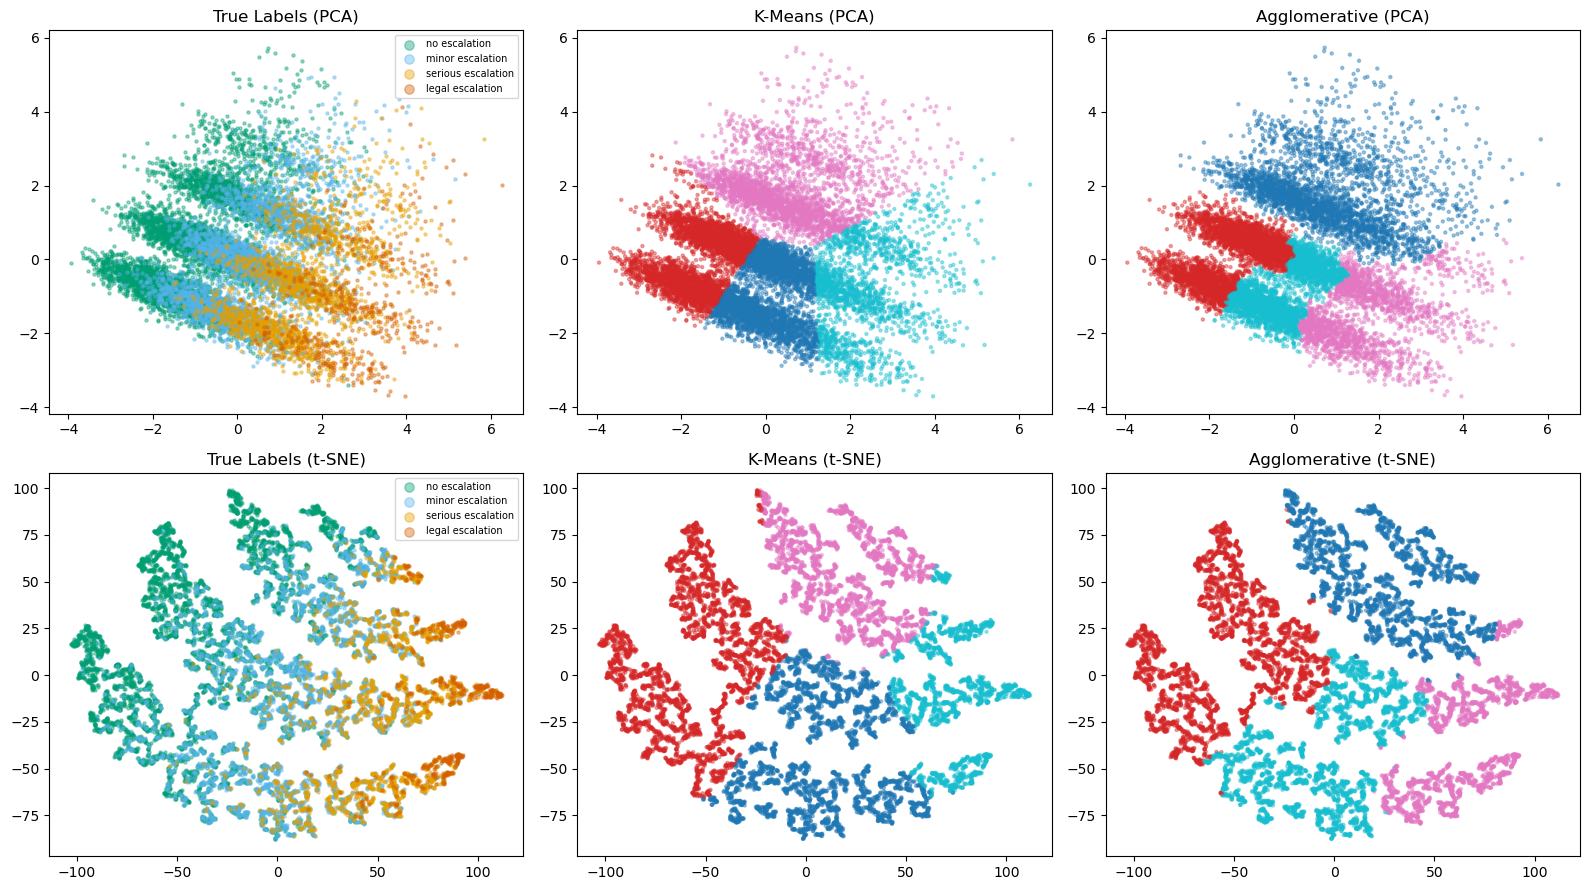

In [55]:
from sklearn.manifold import TSNE

# t-SNE
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_2d)

palette = {'no escalation':'#009E73', 'minor escalation':'#56B4E9',
           'serious escalation':'#E69F00', 'legal escalation':'#D55E00'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# PCA
for lvl, col in palette.items():
    m = y_labels == lvl
    axes[0,0].scatter(X_2d[m,0], X_2d[m,1], c=col, s=5, alpha=0.4, label=lvl)
axes[0,0].set_title('True Labels (PCA)')
axes[0,0].legend(fontsize=7, markerscale=3)

axes[0,1].scatter(X_2d[:,0], X_2d[:,1], c=km_labels, cmap='tab10', s=5, alpha=0.4)
axes[0,1].set_title('K-Means (PCA)')

axes[0,2].scatter(X_2d[:,0], X_2d[:,1], c=agg_labels, cmap='tab10', s=5, alpha=0.4)
axes[0,2].set_title('Agglomerative (PCA)')

# t-SNE
for lvl, col in palette.items():
    m = y_labels == lvl
    axes[1,0].scatter(X_tsne[m,0], X_tsne[m,1], c=col, s=5, alpha=0.4, label=lvl)
axes[1,0].set_title('True Labels (t-SNE)')
axes[1,0].legend(fontsize=7, markerscale=3)

axes[1,1].scatter(X_tsne[:,0], X_tsne[:,1], c=km_labels, cmap='tab10', s=5, alpha=0.4)
axes[1,1].set_title('K-Means (t-SNE)')

axes[1,2].scatter(X_tsne[:,0], X_tsne[:,1], c=agg_labels, cmap='tab10', s=5, alpha=0.4)
axes[1,2].set_title('Agglomerative (t-SNE)')

plt.tight_layout()
plt.show()

## Visualising Cluster to Escalation Level

### Figure 15

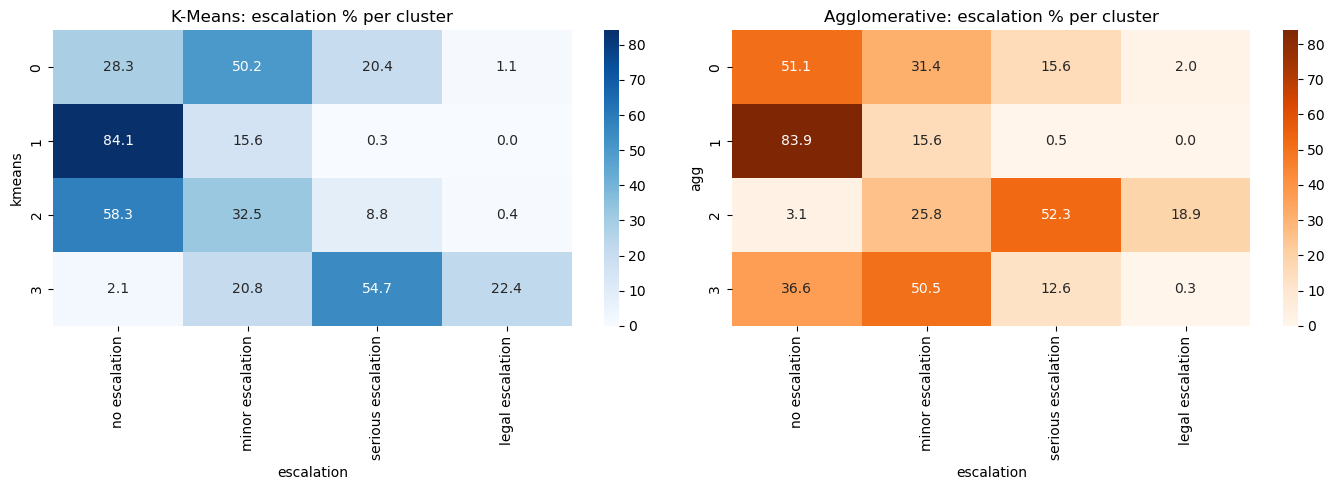

In [56]:
label_order = ['no escalation','minor escalation','serious escalation','legal escalation']

res = pd.DataFrame({'escalation': y_labels, 'kmeans': km_labels, 'agg': agg_labels})

ct_km  = pd.crosstab(res['kmeans'], res['escalation'], normalize='index')[label_order] * 100 #How many customers from K Means cluster belong to each escalation level 
ct_agg = pd.crosstab(res['agg'],    res['escalation'], normalize='index')[label_order] * 100 #For Agglomerative clustering

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(ct_km,  annot=True, fmt='.1f', cmap='Blues',   ax=axes[0])
axes[0].set_title('K-Means: escalation % per cluster')

sns.heatmap(ct_agg, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1])
axes[1].set_title('Agglomerative: escalation % per cluster')

plt.tight_layout()
plt.show()